In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Step 2: Load dataset from the given path
file_path = '/content/New Data for Social Media Covid 19.xlsx'

# Assuming the dataset is an Excel file, load it into a pandas DataFrame
rawData = pd.read_excel(file_path)

# Step 3: Display the first few rows to understand the data

rawData.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,Title,Publication Date,Primary Country,Source Link,Social Media Source,Fact Checked By,Keywords,New Labels
0,Just in: Novel coronavirus named 'Covid-19': U...,2020-02-11,India,https://twitter.com/the_hindu/status/122725962...,twitter.com,The Hindu,Just in: Novel coronavirus named 'Covid-19': U...,Genuine
1,WHO officially names #coronavirus as Covid-19....,2020-02-12,India,https://twitter.com/ndtv/status/12274908434742...,twitter.com,NDTV,WHO officially names #coronavirus as Covid-19....,Genuine
2,"The #UN #health agency announced that ""COVID-1...",2020-02-12,India,https://twitter.com/the_hindu/status/122744471...,twitter.com,The Hindu,"The #UN #health agency announced that ""COVID-1...",Genuine
3,The Indian Embassy in Tokyo has said that one ...,2020-02-14,India,https://twitter.com/IndiaToday/status/12282764...,twitter.com,IndiaToday,The Indian Embassy in Tokyo has said that one ...,Genuine
4,Ground Zero | How Kerala used its experience i...,2020-02-15,India,https://twitter.com/the_hindu/status/122854247...,twitter.com,The Hindu,Ground Zero | How Kerala used its experience i...,Genuine


In [ ]:
# Get the total number of rows in the dataframe
row_count = len(rawData)

# Print the total number of rows
print(row_count)

14466


In [ ]:
# Step 1.2: Exploring the dataset

# Check for basic information on the data
rawData.info()

# Check for any missing values
print("\nMissing Values:")
print(rawData.isnull().sum())

# Check the distribution of the target labels
print("\nLabel Distribution:")
print(rawData['New Labels'].value_counts())

# Display some example titles and their corresponding labels
print("\nExample Titles and New Labels:")
print(rawData[['Title', 'New Labels']].sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14466 entries, 0 to 14465
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Title                14466 non-null  object        
 1   Publication Date     14466 non-null  datetime64[ns]
 2   Primary Country      14466 non-null  object        
 3   Source Link          14466 non-null  object        
 4   Social Media Source  14466 non-null  object        
 5   Fact Checked By      14466 non-null  object        
 6   Keywords             14466 non-null  object        
 7   New Labels           14466 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 904.3+ KB

Missing Values:
Title                  0
Publication Date       0
Primary Country        0
Source Link            0
Social Media Source    0
Fact Checked By        0
Keywords               0
New Labels             0
dtype: int64

Label Distribution:
New Labels

<ipython-input-5-b3c17d9772bf>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='New Labels', data=rawData, palette='viridis')


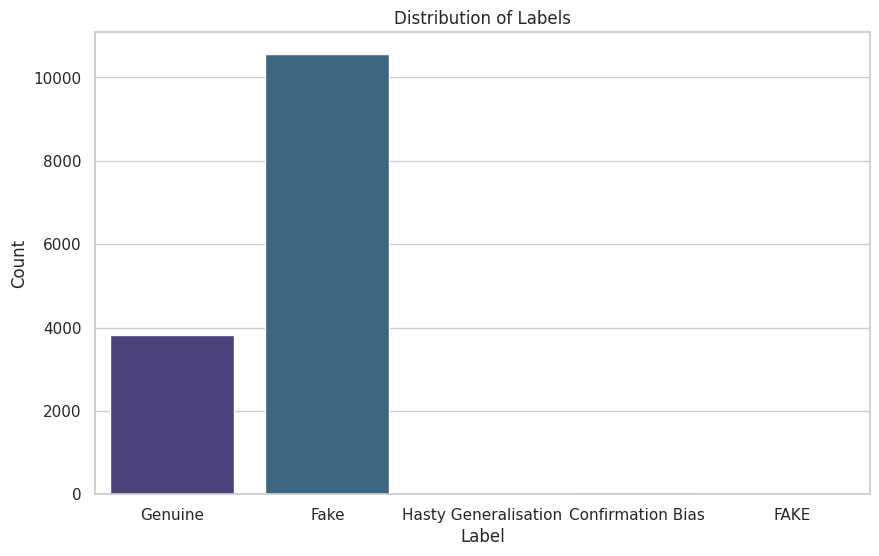

<ipython-input-5-b3c17d9772bf>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sources.values, y=top_sources.index, palette='magma')


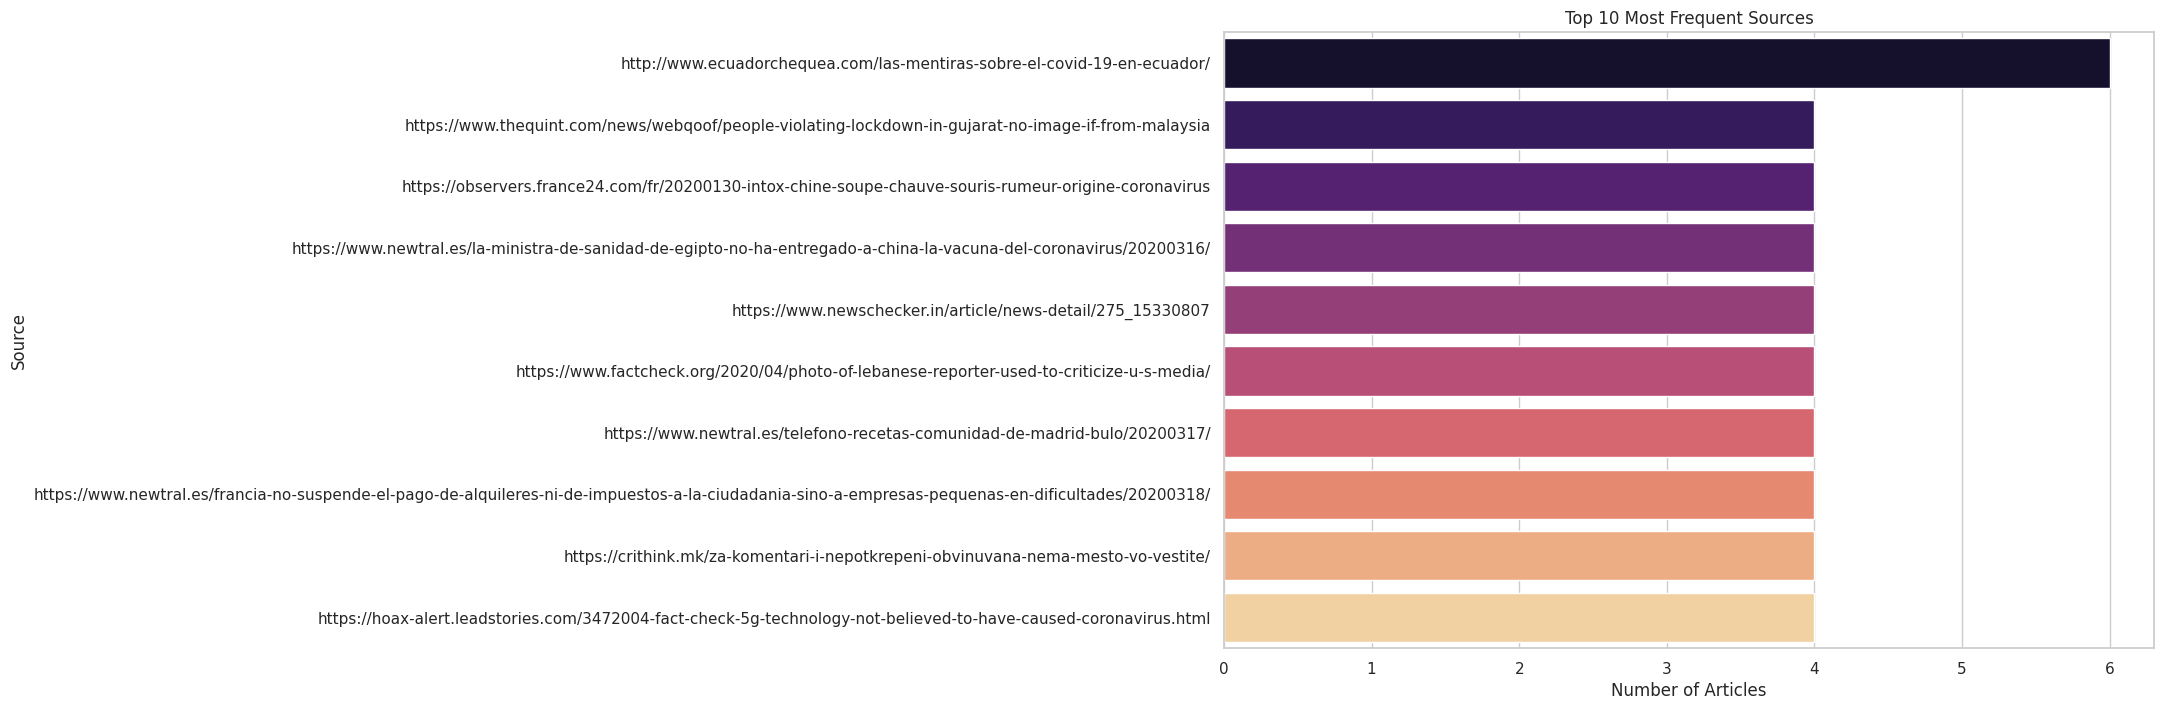

<ipython-input-5-b3c17d9772bf>:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rawData['Publication Date'].value_counts().resample('M').count().plot()


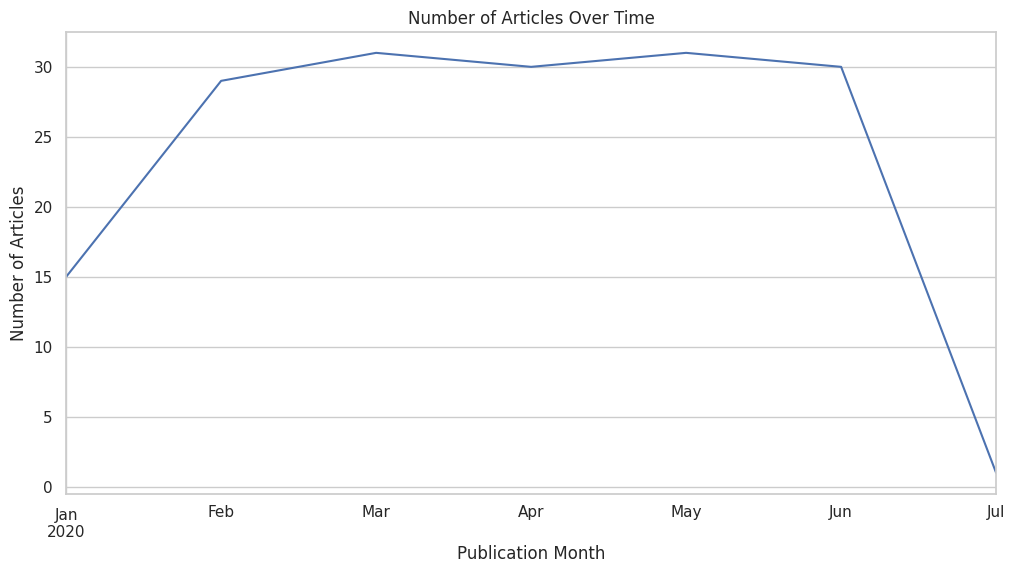

In [ ]:
 import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
sns.set(style='whitegrid')

# Plot the distribution of labels
plt.figure(figsize=(10, 6))
sns.countplot(x='New Labels', data=rawData, palette='viridis')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Plot the top 10 most frequent sources
plt.figure(figsize=(12, 8))
top_sources = rawData['Source Link'].value_counts().nlargest(10)
sns.barplot(x=top_sources.values, y=top_sources.index, palette='magma')
plt.title('Top 10 Most Frequent Sources')
plt.xlabel('Number of Articles')
plt.ylabel('Source')
plt.show()

# Plot the publication dates if they exist in a format that allows date analysis
if 'Publication Date' in rawData.columns:
    # Convert the Publication Date column to datetime if it's not already
    rawData['Publication Date'] = pd.to_datetime(rawData['Publication Date'], errors='coerce')

    # Plot the distribution of articles over time
    plt.figure(figsize=(12, 6))
    rawData['Publication Date'].value_counts().resample('M').count().plot()
    plt.title('Number of Articles Over Time')
    plt.xlabel('Publication Month')
    plt.ylabel('Number of Articles')
    plt.show()

In [ ]:
# Replace all occurrences of 'FAKE' with 'Fake' in the 'New Labels' column
rawData['New Labels'] = rawData['New Labels'].replace('FAKE', 'Fake')


In [ ]:
print(rawData['New Labels'].value_counts())

New Labels
Fake                    10561
Genuine                  3824
Confirmation Bias          56
Hasty Generalisation       25
Name: count, dtype: int64


In [ ]:
# Import necessary libraries
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Step 2.1: Cleaning the data
def clean_text(text):
    # Remove non-alphabetic characters
    text = re.sub(r'[^A-Za-z\s]', '', str(text))
    # Convert text to lowercase
    text = text.lower()
    return text

# Apply the cleaning function to the Title column
rawData['Cleaned_Title'] = rawData['Title'].apply(lambda x: clean_text(x))

# Check a few examples to see if the cleaning worked
print("\nFirst 5 cleaned titles:")
print(rawData['Cleaned_Title'].head())



First 5 cleaned titles:
0    just in novel coronavirus named covid un healt...
1    who officially names coronavirus as covid\n ht...
2    the un health agency announced that covid will...
3    the indian embassy in tokyo has said that one ...
4    ground zero  how kerala used its experience in...
Name: Cleaned_Title, dtype: object


In [ ]:
# Step 2.2: Tokenization, Stop-Word Removal, and Lemmatization
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Tokenization
    tokens = text.split()
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

# Apply the preprocessing function to the Cleaned_Title column
rawData['Processed_Title'] = rawData['Cleaned_Title'].apply(lambda x: preprocess_text(x))

# Check if the processed titles are correctly created
print("\nFirst 5 processed titles:")
print(rawData['Processed_Title'].head())


First 5 processed titles:
0    novel coronavirus named covid un health agency...
1    officially name coronavirus covid httpswwwndtv...
2    un health agency announced covid official name...
3    indian embassy tokyo said one indian crew memb...
4    ground zero kerala used experience controlling...
Name: Processed_Title, dtype: object


In [ ]:
# Step 5.3: Analyzing Text Features - Calculate Title Length
# Calculate the length of each title
rawData['Title_Length'] = rawData['Title'].apply(lambda x: len(str(x).split()))

# Display summary statistics of title length
print("\nTitle Length Statistics:")
print(rawData['Title_Length'].describe())


Title Length Statistics:
count    14466.000000
mean        17.507742
std          9.588836
min          1.000000
25%         11.000000
50%         15.000000
75%         22.000000
max         84.000000
Name: Title_Length, dtype: float64


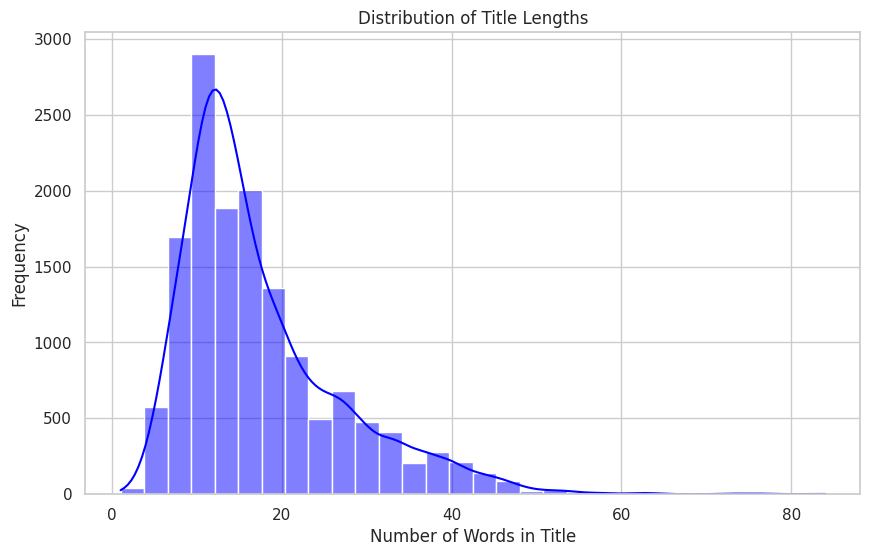

In [ ]:
# Plot the distribution of title lengths
plt.figure(figsize=(10, 6))
sns.histplot(rawData['Title_Length'], bins=30, kde=True, color='blue')
plt.title('Distribution of Title Lengths')
plt.xlabel('Number of Words in Title')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Step 5.4: Analyzing the average word frequency in the processed titles
from collections import Counter

# Ensure there are no missing or incorrect entries in 'Processed_Title'
rawData['Processed_Title'] = rawData['Processed_Title'].fillna('')

# Get a list of all words from the processed titles
all_words = ' '.join(rawData['Processed_Title']).split()

# Count the frequency of each word
word_freq = Counter(all_words)

# Get the 10 most common words
common_words = word_freq.most_common(10)
print("\nTop 10 Most Common Words in Titles:")
print(common_words)


Top 10 Most Common Words in Titles:
[('covid', 7012), ('coronavirus', 5106), ('people', 1362), ('video', 1146), ('case', 1105), ('india', 990), ('lockdown', 927), ('show', 921), ('new', 866), ('claim', 816)]


<ipython-input-14-4cfa2f4fa807>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='rocket')


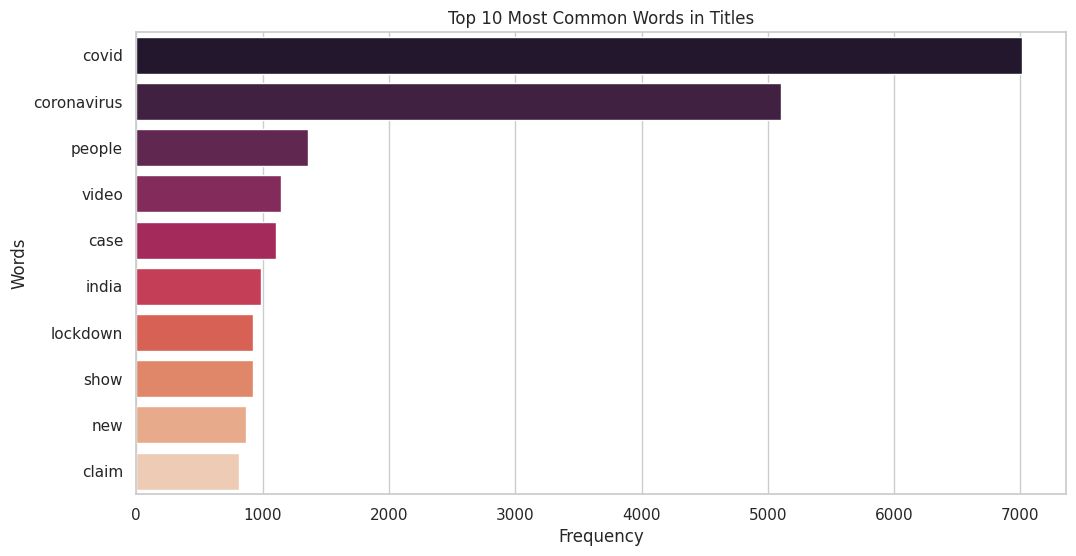

In [ ]:
# Plot the most common words
words, counts = zip(*common_words)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette='rocket')
plt.title('Top 10 Most Common Words in Titles')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()


Correlation Matrix:
              Title_Length
Title_Length           1.0


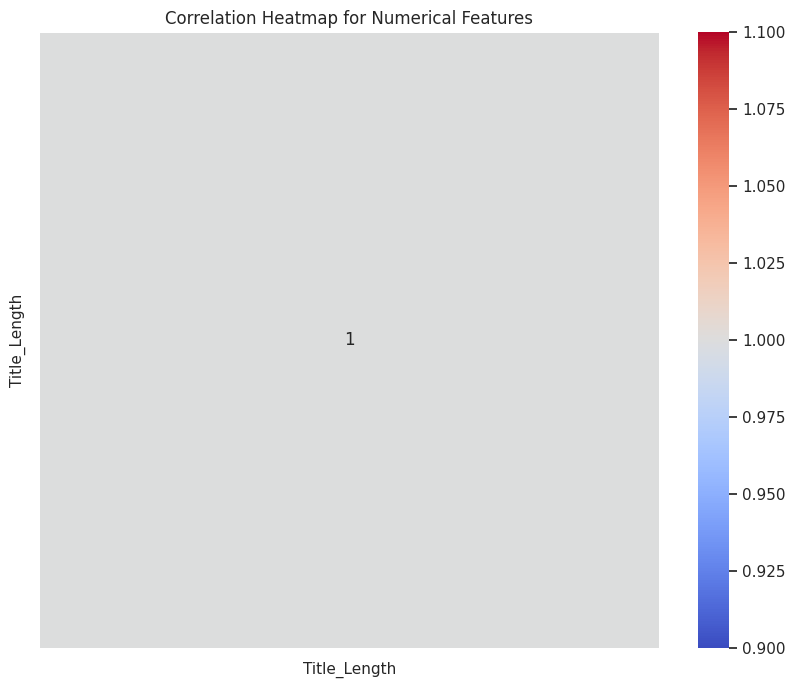

In [ ]:
# Step 5.4.1: Correlation Analysis for Numerical Features

# Select only numerical columns from the dataset
numerical_df = rawData.select_dtypes(include=['number'])

# Check if there are any numerical columns to work with
if not numerical_df.empty:
    # Compute correlation matrix for numerical features
    correlation_matrix = numerical_df.corr()

    # Display the correlation matrix
    print("\nCorrelation Matrix:")
    print(correlation_matrix)

    # Plot the correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Heatmap for Numerical Features')
    plt.show()
else:
    print("No numerical columns available for correlation analysis.")


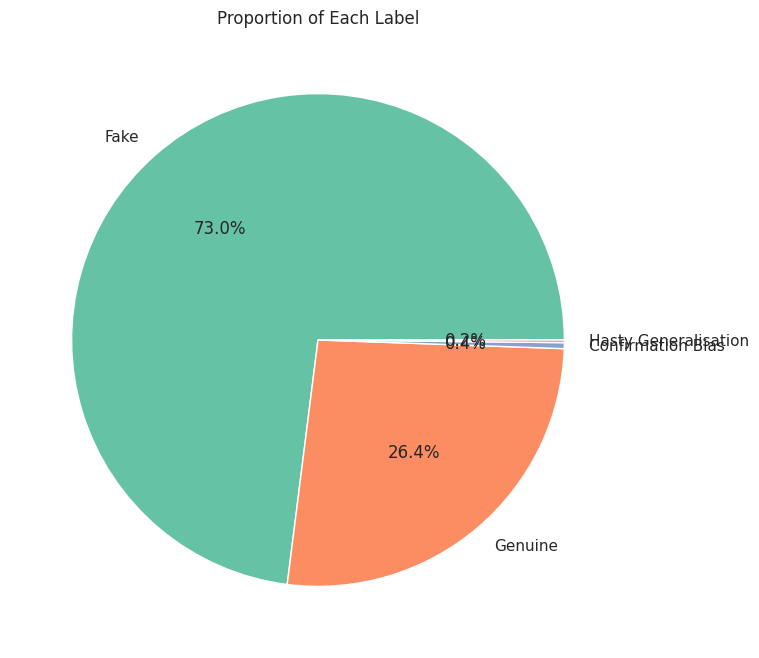

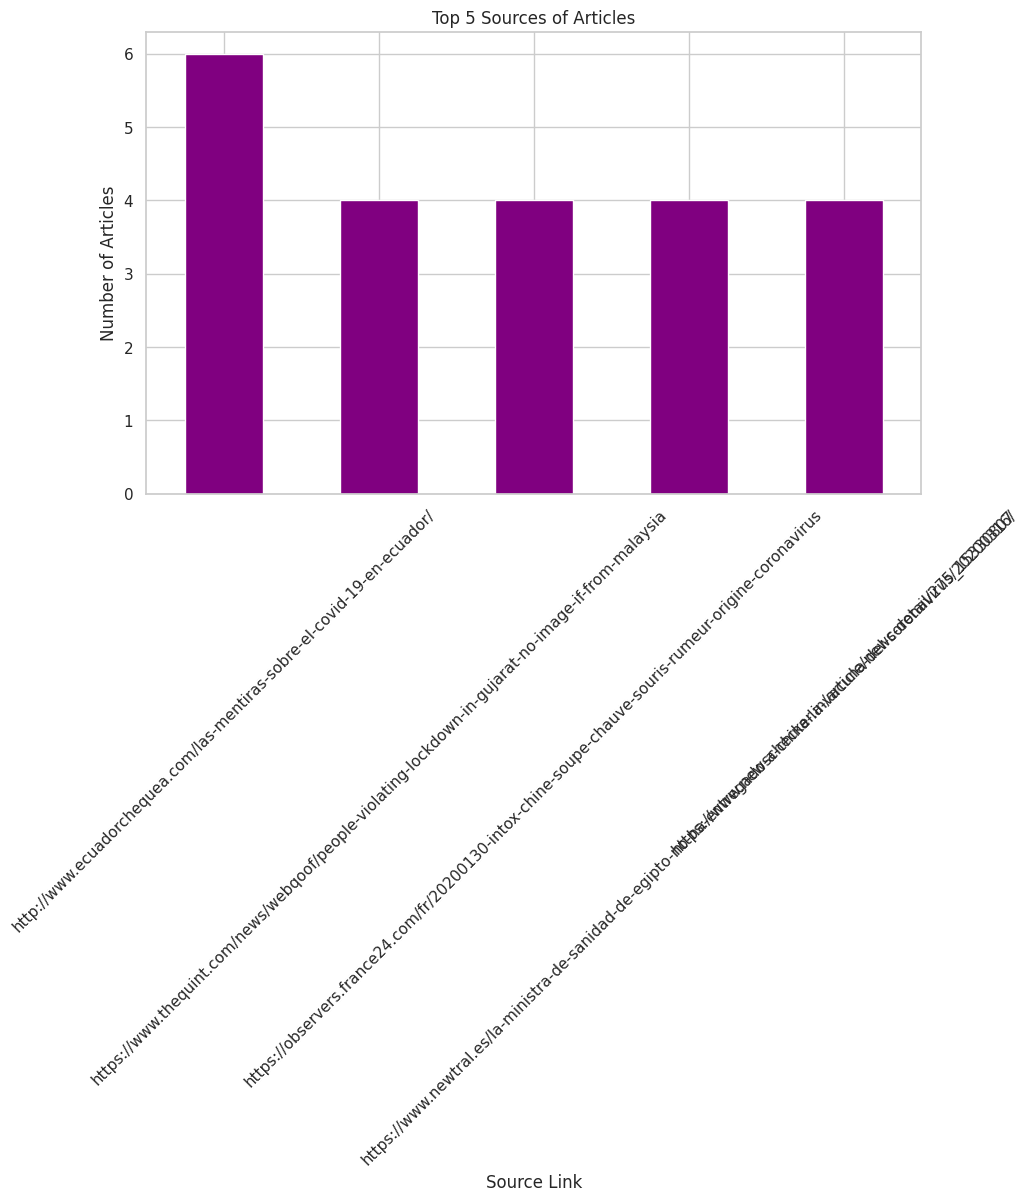

In [ ]:
# Step 5.4.2: Categorical Analysis - Label Proportions

# Plot the proportion of each label in the 'New Labels' column as a pie chart
plt.figure(figsize=(8, 8))
rawData['New Labels'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Proportion of Each Label')
plt.ylabel('')
plt.show()

# Analyzing source diversity (top 5 sources) from the 'Source Link' column
plt.figure(figsize=(10, 6))
rawData['Source Link'].value_counts().nlargest(5).plot(kind='bar', color='purple')
plt.title('Top 5 Sources of Articles')
plt.xlabel('Source Link')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

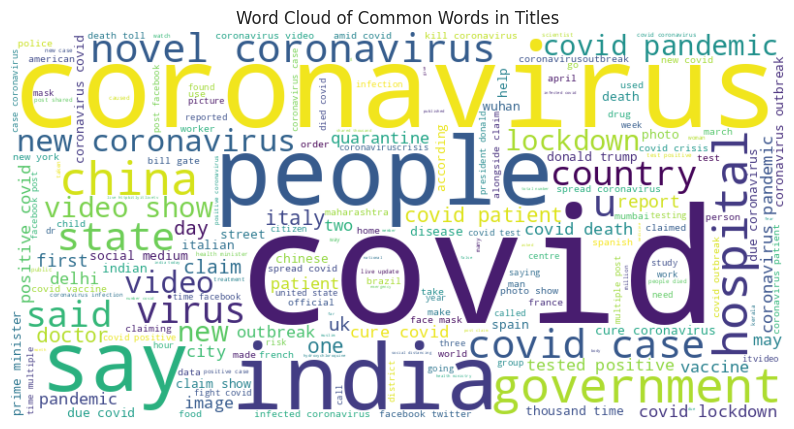

In [ ]:
from wordcloud import WordCloud

# Step 5.4.3: Generating a Word Cloud for Processed Titles

# Create a single string of all processed titles from the 'Processed_Title' column
all_processed_titles = ' '.join(rawData['Processed_Title'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_processed_titles)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Common Words in Titles')
plt.show()

<ipython-input-18-c3b5c24e9280>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='New Labels', y='Title_Length', data=rawData, palette='Set3')


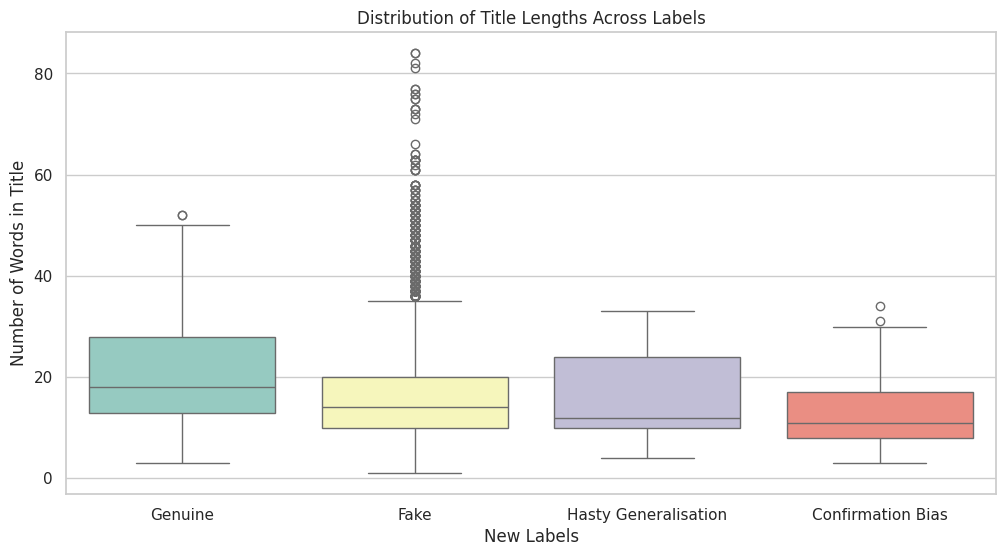

In [ ]:
# Step 5.4.4: Distribution of Article Lengths Across Labels

plt.figure(figsize=(12, 6))
sns.boxplot(x='New Labels', y='Title_Length', data=rawData, palette='Set3')
plt.title('Distribution of Title Lengths Across Labels')
plt.xlabel('New Labels')
plt.ylabel('Number of Words in Title')
plt.show()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...



Sentiment Score Statistics:
count    14466.000000
mean        -0.066091
std          0.375036
min         -0.971200
25%         -0.340000
50%          0.000000
75%          0.051600
max          0.927400
Name: Sentiment_Score, dtype: float64


<ipython-input-19-b626182767a7>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='New Labels', y='Sentiment_Score', data=rawData, palette='coolwarm')


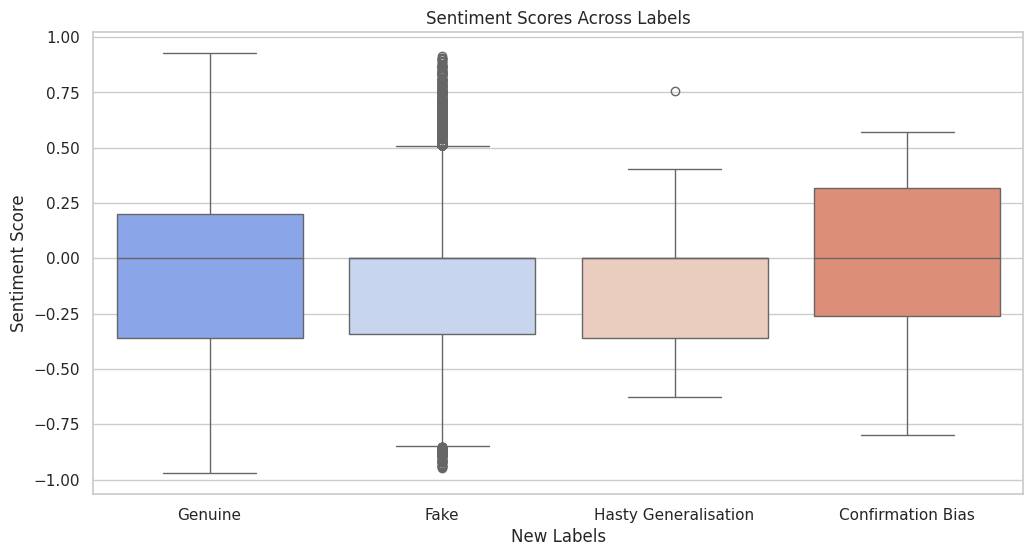

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download necessary NLTK resources
nltk.download('vader_lexicon')

# Step 5.4.5: Sentiment Analysis of Titles

# Initialize Sentiment Intensity Analyzer
sia = SentimentIntensityAnalyzer()

# Apply sentiment analysis to each title in the 'Title' column and store the compound score
rawData['Sentiment_Score'] = rawData['Title'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Summary statistics for sentiment score
print("\nSentiment Score Statistics:")
print(rawData['Sentiment_Score'].describe())

# Plot sentiment scores by label from the 'New Labels' column
plt.figure(figsize=(12, 6))
sns.boxplot(x='New Labels', y='Sentiment_Score', data=rawData, palette='coolwarm')
plt.title('Sentiment Scores Across Labels')
plt.xlabel('New Labels')
plt.ylabel('Sentiment Score')
plt.show()



Label Distribution Before Handling Imbalance:
New Labels
Fake                    10561
Genuine                  3824
Confirmation Bias          56
Hasty Generalisation       25
Name: count, dtype: int64


<ipython-input-20-01d935c77564>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='New Labels', data=rawData, palette='viridis')


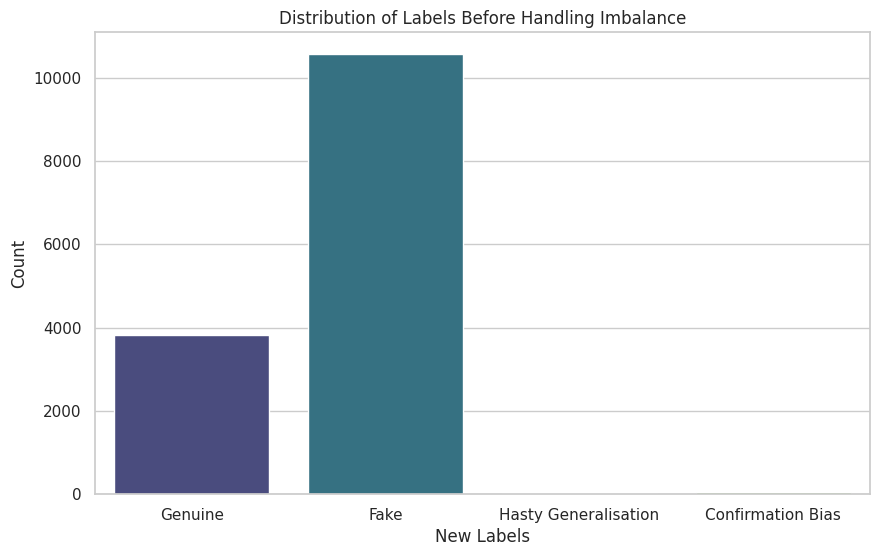

In [ ]:
# Step 6.1: Handling Class Imbalance

# Inspect label distribution in the 'New Labels' column
print("\nLabel Distribution Before Handling Imbalance:")
print(rawData['New Labels'].value_counts())

# Plot label distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='New Labels', data=rawData, palette='viridis')
plt.title('Distribution of Labels Before Handling Imbalance')
plt.xlabel('New Labels')
plt.ylabel('Count')
plt.show()


Label Distribution After Oversampling:
New Labels
Fake                    10561
Genuine                 10350
Confirmation Bias         139
Hasty Generalisation       72
Name: count, dtype: int64


<ipython-input-21-6164dc1cfd8b>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='New Labels', data=df_balanced, palette='viridis')


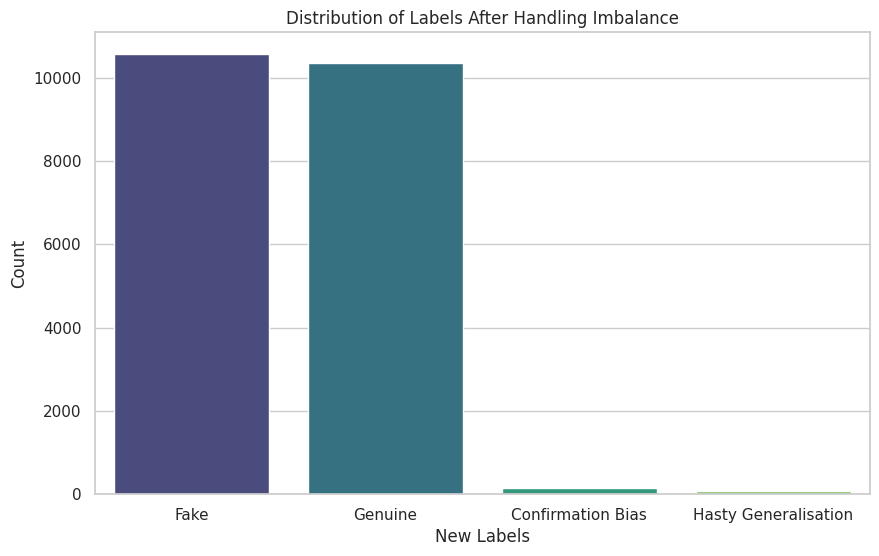

In [ ]:
from sklearn.utils import resample

# Step 6.2: Handling Class Imbalance by Oversampling

# Separate majority and minority classes based on the 'New Labels' column
df_majority = rawData[rawData['New Labels'] == rawData['New Labels'].value_counts().idxmax()]
df_minority = rawData[rawData['New Labels'] != rawData['New Labels'].value_counts().idxmax()]

# Oversample the minority class to match the majority class count
df_minority_oversampled = resample(df_minority,
                                   replace=True,
                                   n_samples=len(df_majority),
                                   random_state=42)

# Combine majority class with oversampled minority class
df_balanced = pd.concat([df_majority, df_minority_oversampled])

# Shuffle the data to ensure a good mix of majority and minority samples
df_balanced = df_balanced.sample(frac=1, random_state=42)

# Display new label distribution
print("\nLabel Distribution After Oversampling:")
print(df_balanced['New Labels'].value_counts())

# Plot new label distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='New Labels', data=df_balanced, palette='viridis')
plt.title('Distribution of Labels After Handling Imbalance')
plt.xlabel('New Labels')
plt.ylabel('Count')
plt.show()


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Step 6.3: Handling Class Imbalance Using SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Create feature matrix (X) and labels (y) from the balanced dataset
X = df_balanced['Processed_Title']
y = df_balanced['New Labels']

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X).toarray()

# Apply SMOTE to balance the dataset
X_resampled, y_resampled = smote.fit_resample(X, y)

# Display the new label distribution after SMOTE
unique, counts = np.unique(y_resampled, return_counts=True)
print("\nLabel Distribution After Applying SMOTE:")
print(dict(zip(unique, counts)))



Label Distribution After Applying SMOTE:
{'Confirmation Bias': 10561, 'Fake': 10561, 'Genuine': 10561, 'Hasty Generalisation': 10561}


In [ ]:
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Step 6.6: Handling Class Imbalance Using EasyEnsembleClassifier

# Create feature matrix (X) and labels (y)
X = rawData['Processed_Title']
y = rawData['New Labels']

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X).toarray()

# Split the data into training and testing sets (using only training data to balance)
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the EasyEnsembleClassifier
easy_ensemble = EasyEnsembleClassifier(random_state=42, n_estimators=10)

# Fit the EasyEnsembleClassifier to generate balanced subsets
easy_ensemble.fit(X_train, y_train)

# Collect the balanced data from each of the sub-models (estimators)
balanced_X = []
balanced_y = []

# Loop through each estimator to collect balanced samples
for estimator in easy_ensemble.estimators_:
    # Each estimator is trained on a balanced subset of the data
    # Extract the indices of the samples used by this estimator
    sampled_indices = estimator[0].sample_indices_
    balanced_X.append(X_train[sampled_indices])
    balanced_y.append(np.array(y_train)[sampled_indices])

# Combine all the balanced data from each of the weak learners
balanced_X = np.vstack(balanced_X)
balanced_y = np.hstack(balanced_y)

# Create a balanced DataFrame for easier analysis or further use
balanced_data = pd.DataFrame(balanced_X, columns=[f'Feature_{i}' for i in range(balanced_X.shape[1])])
balanced_data['New Labels'] = balanced_y

# Display the new label distribution after handling imbalance
print("\nLabel Distribution After Handling Imbalance Using EasyEnsembleClassifier:")
print(balanced_data['New Labels'].value_counts())
# The balanced_data DataFrame is now ready for further analysis or model training


Label Distribution After Handling Imbalance Using EasyEnsembleClassifier:
New Labels
Confirmation Bias       200
Fake                    200
Genuine                 200
Hasty Generalisation    200
Name: count, dtype: int64


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Step 6.5: Handling Class Imbalance Using Random Under-Sampling

# Initialize Random Under-Sampler
under_sampler = RandomUnderSampler(random_state=42)

# Create feature matrix (X) and labels (y) from the balanced dataset
X = df_balanced['Processed_Title']
y = df_balanced['New Labels']

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X).toarray()

# Apply Random Under-Sampling to balance the dataset
X_resampled, y_resampled = under_sampler.fit_resample(X, y)

# Display the new label distribution after under-sampling
unique, counts = np.unique(y_resampled, return_counts=True)
print("\nLabel Distribution After Applying Random Under-Sampling:")
print(dict(zip(unique, counts)))


Label Distribution After Applying Random Under-Sampling:
{'Confirmation Bias': 72, 'Fake': 72, 'Genuine': 72, 'Hasty Generalisation': 72}


In [ ]:
from sklearn.preprocessing import StandardScaler

# Apply standard scaling to the numerical features after balancing
scaler = StandardScaler()

# Select numerical features from df_balanced, excluding Title_Length to avoid re-scaling
numerical_features = df_balanced.select_dtypes(include=['number']).drop(columns=['Title_Length'], errors='ignore')

# Scale numerical features
scaled_features = scaler.fit_transform(numerical_features)

# Replace numerical columns with their scaled values in df_balanced
for i, col in enumerate(numerical_features.columns):
    df_balanced[col] = scaled_features[:, i]

print("\nNumerical Features After Scaling:")
print(df_balanced.describe())



Numerical Features After Scaling:
                    Publication Date  Title_Length  Sentiment_Score
count                          21122  21122.000000     2.112200e+04
mean   2020-04-15 09:00:17.384717312     18.672285    -1.480157e-17
min              2020-01-04 00:00:00      1.000000    -2.375658e+00
25%              2020-03-22 00:00:00     12.000000    -7.298008e-01
50%              2020-04-11 00:00:00     15.000000     1.567511e-01
75%              2020-05-08 00:00:00     24.000000     3.580505e-01
max              2020-07-01 00:00:00     84.000000     2.574952e+00
std                              NaN      9.895480     1.000024e+00


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import numpy as np

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Create feature matrix (X) and labels (y)
X = rawData['Processed_Title']
y = rawData['New Labels']

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X).toarray()

# Apply SMOTE to balance the dataset
X_resampled, y_resampled = smote.fit_resample(X, y)

# Standard scaling for the resampled data (SMOTE)
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

print("\nNumerical Features After Applying SMOTE and Scaling:")
print(X_resampled_scaled[:5])  # Print first 5 rows for checking



Numerical Features After Applying SMOTE and Scaling:
[[-0.0135611  -0.01664387 -0.02420671 ... -0.00971206 -0.01359601
  -0.01522289]
 [-0.0135611  -0.01664387 -0.02420671 ... -0.00971206 -0.01359601
  -0.01522289]
 [-0.0135611  -0.01664387 -0.02420671 ... -0.00971206 -0.01359601
  -0.01522289]
 [-0.0135611  -0.01664387 -0.02420671 ... -0.00971206 -0.01359601
  -0.01522289]
 [-0.0135611  -0.01664387 -0.02420671 ... -0.00971206 -0.01359601
  -0.01522289]]


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import numpy as np

# Initialize Random Under-Sampler
under_sampler = RandomUnderSampler(random_state=42)

# Create feature matrix (X) and labels (y)
X = rawData['Processed_Title']
y = rawData['New Labels']

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X).toarray()

# Apply Random Under-Sampling to balance the dataset
X_resampled, y_resampled = under_sampler.fit_resample(X, y)

# Standard scaling for the resampled data (Random Under-Sampling)
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

print("\nNumerical Features After Applying Random Under-Sampling and Scaling:")
print(X_resampled_scaled[:5])  # Print first 5 rows for checking



Numerical Features After Applying Random Under-Sampling and Scaling:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Create feature matrix (X) and labels (y)
X = rawData['Processed_Title']
y = rawData['New Labels']

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X).toarray()

# Split the data into training and testing sets (using only training data to balance)
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the EasyEnsembleClassifier
easy_ensemble = EasyEnsembleClassifier(random_state=42, n_estimators=10)

# Fit the EasyEnsembleClassifier to generate balanced subsets
easy_ensemble.fit(X_train, y_train)

# Collect the balanced data from each of the sub-models (estimators)
balanced_X = []
balanced_y = []

# Loop through each estimator to collect balanced samples
for estimator in easy_ensemble.estimators_:
    # Each estimator is trained on a balanced subset of the data
    # Extract the indices of the samples used by this estimator
    sampled_indices = estimator[0].sample_indices_
    balanced_X.append(X_train[sampled_indices])
    balanced_y.append(np.array(y_train)[sampled_indices])

# Combine all the balanced data from each of the weak learners
balanced_X = np.vstack(balanced_X)
balanced_y = np.hstack(balanced_y)

# Standard scaling for the resampled data (EasyEnsembleClassifier)
scaler = StandardScaler()
balanced_X_scaled = scaler.fit_transform(balanced_X)

# Create a DataFrame for easier analysis or further use
balanced_data = pd.DataFrame(balanced_X_scaled, columns=[f'Feature_{i}' for i in range(balanced_X_scaled.shape[1])])
balanced_data['New Labels'] = balanced_y

print("\nLabel Distribution After Handling Imbalance Using EasyEnsembleClassifier and Scaling:")
print(balanced_data['New Labels'].value_counts())


Label Distribution After Handling Imbalance Using EasyEnsembleClassifier and Scaling:
New Labels
Confirmation Bias       200
Fake                    200
Genuine                 200
Hasty Generalisation    200
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# Step 6.4: Splitting the original dataset (without balancing) into training and test sets

# Create feature matrix (X) and labels (y)
X = rawData['Processed_Title']
y = rawData['New Labels']

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X).toarray()

# Standard scaling for the original dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes to ensure data is split properly
print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")

# Display label distribution in train and test set to confirm stratification
print("\nLabel Distribution in Training Set:")
print(pd.Series(y_train).value_counts())
print("\nLabel Distribution in Test Set:")
print(pd.Series(y_test).value_counts())

Training set size: (11572, 5000), Test set size: (2894, 5000)

Label Distribution in Training Set:
New Labels
Fake                    8448
Genuine                 3059
Confirmation Bias         45
Hasty Generalisation      20
Name: count, dtype: int64

Label Distribution in Test Set:
New Labels
Fake                    2113
Genuine                  765
Confirmation Bias         11
Hasty Generalisation       5
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE

# Step 6.4: Applying SMOTE and Splitting the balanced dataset into training and test sets

# Create feature matrix (X) and labels (y)
X = rawData['Processed_Title']
y = rawData['New Labels']

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X).toarray()

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Standard scaling for the resampled dataset (SMOTE)
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

# Split the balanced dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled_scaled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Display the shapes to ensure data is split properly
print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")

# Display label distribution in train and test set to confirm stratification
print("\nLabel Distribution in Training Set:")
print(pd.Series(y_train).value_counts())
print("\nLabel Distribution in Test Set:")
print(pd.Series(y_test).value_counts())

Training set size: (33795, 5000), Test set size: (8449, 5000)

Label Distribution in Training Set:
New Labels
Fake                    8449
Hasty Generalisation    8449
Confirmation Bias       8449
Genuine                 8448
Name: count, dtype: int64

Label Distribution in Test Set:
New Labels
Genuine                 2113
Hasty Generalisation    2112
Fake                    2112
Confirmation Bias       2112
Name: count, dtype: int64


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Step 6.4: Applying Random Under-Sampling and Splitting the balanced dataset into training and test sets

# Create feature matrix (X) and labels (y)
X = rawData['Processed_Title']
y = rawData['New Labels']

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X).toarray()

# Apply Random Under-Sampling to balance the dataset
under_sampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = under_sampler.fit_resample(X, y)

# Standard scaling for the resampled dataset (Random Under-Sampling)
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

# Split the balanced dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled_scaled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Display the shapes to ensure data is split properly
print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")

# Display label distribution in train and test set to confirm stratification
print("\nLabel Distribution in Training Set:")
print(pd.Series(y_train).value_counts())
print("\nLabel Distribution in Test Set:")
print(pd.Series(y_test).value_counts())

Training set size: (80, 5000), Test set size: (20, 5000)

Label Distribution in Training Set:
New Labels
Hasty Generalisation    20
Genuine                 20
Fake                    20
Confirmation Bias       20
Name: count, dtype: int64

Label Distribution in Test Set:
New Labels
Genuine                 5
Confirmation Bias       5
Fake                    5
Hasty Generalisation    5
Name: count, dtype: int64


In [ ]:
from imblearn.ensemble import EasyEnsembleClassifier
import numpy as np

# Step 6.4: Applying EasyEnsembleClassifier and Splitting the balanced dataset into training and test sets

# Create feature matrix (X) and labels (y)
X = rawData['Processed_Title']
y = rawData['New Labels']

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X).toarray()

# Split the data into training and testing sets (only for balancing)
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize EasyEnsembleClassifier to generate balanced subsets
easy_ensemble = EasyEnsembleClassifier(random_state=42, n_estimators=10)

# Fit the classifier to generate balanced subsets
easy_ensemble.fit(X_train, y_train)

# Collect the balanced data from each of the weak learners
balanced_X = []
balanced_y = []

# Loop through each estimator to collect balanced samples
for estimator in easy_ensemble.estimators_:
    sampled_indices = estimator[0].sample_indices_
    balanced_X.append(X_train[sampled_indices])
    balanced_y.append(np.array(y_train)[sampled_indices])

# Combine all the balanced data from each of the weak learners
balanced_X = np.vstack(balanced_X)
balanced_y = np.hstack(balanced_y)

# Standard scaling for the resampled dataset (EasyEnsembleClassifier)
scaler = StandardScaler()
balanced_X_scaled = scaler.fit_transform(balanced_X)

# Split the balanced dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(balanced_X_scaled, balanced_y, test_size=0.2, random_state=42, stratify=balanced_y)

# Display the shapes to ensure data is split properly
print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")

# Display label distribution in train and test set to confirm stratification
print("\nLabel Distribution in Training Set:")
print(pd.Series(y_train).value_counts())
print("\nLabel Distribution in Test Set:")
print(pd.Series(y_test).value_counts())

Training set size: (640, 5000), Test set size: (160, 5000)

Label Distribution in Training Set:
Confirmation Bias       160
Fake                    160
Genuine                 160
Hasty Generalisation    160
Name: count, dtype: int64

Label Distribution in Test Set:
Genuine                 40
Fake                    40
Hasty Generalisation    40
Confirmation Bias       40
Name: count, dtype: int64


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize necessary NLP tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Tokenization
    tokens = text.split()
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

# Apply the preprocessing function to the Cleaned_Title column
rawData['Processed_Title'] = rawData['Cleaned_Title'].apply(lambda x: preprocess_text(x))

# Display the processed text
print(rawData[['Title', 'Cleaned_Title', 'Processed_Title']].sample(5))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                                   Title  \
4531    A dog vaccine can be used against coronavirus...   
2086   #Business | RIL said the partnership with Silv...   
14119           Actor Tom Hanks died due to coronavirus.   
7210    Image of patients lying on rope-beds out in t...   
11648  This video purports to show body bags for viru...   

                                           Cleaned_Title  \
4531    a dog vaccine can be used against coronavirus...   
2086   business  ril said the partnership with silver...   
14119            actor tom hanks died due to coronavirus   
7210    image of patients lying on ropebeds out in th...   
11648  this video purports to show body bags for viru...   

                                         Processed_Title  
4531                 dog vaccine used coronavirus people  
2086   business ril said partnership silver lake spec...  
14119                actor tom hank died due coronavirus  
7210   image patient lying ropebeds open c

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(rawData['Processed_Title']).toarray()
y = rawData['New Labels']

# Standard scaling for original dataset (without balancing)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Display label distribution in train and test set to confirm stratification
print("\nOriginal Dataset - Label Distribution in Training Set:")
print(pd.Series(y_train).value_counts())
print("\nOriginal Dataset - Label Distribution in Test Set:")
print(pd.Series(y_test).value_counts())


Original Dataset - Label Distribution in Training Set:
New Labels
Fake                    8448
Genuine                 3059
Confirmation Bias         45
Hasty Generalisation      20
Name: count, dtype: int64

Original Dataset - Label Distribution in Test Set:
New Labels
Fake                    2113
Genuine                  765
Confirmation Bias         11
Hasty Generalisation       5
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(rawData['Processed_Title']).toarray()
y = rawData['New Labels']

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Standard scaling for SMOTE dataset
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

# Split the balanced dataset into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_resampled_scaled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Display label distribution in train and test set to confirm stratification
print("\nSMOTE Balanced Dataset - Label Distribution in Training Set:")
print(pd.Series(y_train).value_counts())
print("\nSMOTE Balanced Dataset - Label Distribution in Test Set:")
print(pd.Series(y_test).value_counts())


SMOTE Balanced Dataset - Label Distribution in Training Set:
New Labels
Fake                    8449
Hasty Generalisation    8449
Confirmation Bias       8449
Genuine                 8448
Name: count, dtype: int64

SMOTE Balanced Dataset - Label Distribution in Test Set:
New Labels
Genuine                 2113
Hasty Generalisation    2112
Fake                    2112
Confirmation Bias       2112
Name: count, dtype: int64


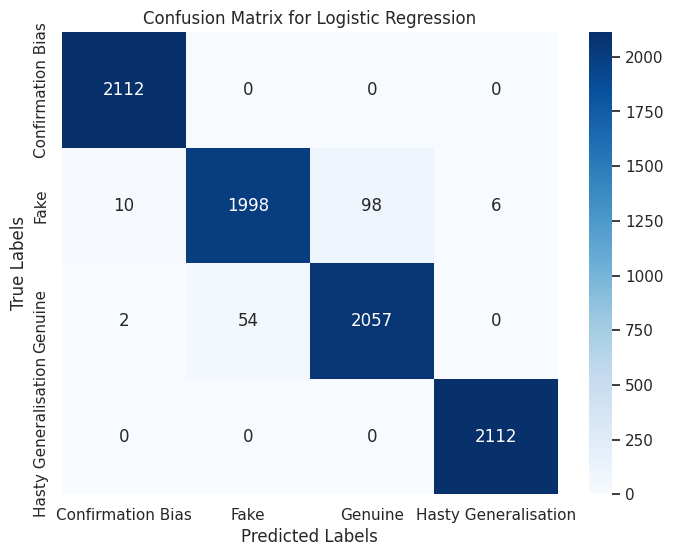

NameError: name 'evaluate_model' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, model_name):
  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
  plt.title(f"Confusion Matrix for {model_name}")
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.show()


# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
plot_confusion_matrix(y_test, y_pred_logreg, "Logistic Regression")
evaluate_model("Logistic Regression", y_test, y_pred_logreg, metric)


# Support Vector Machine
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
plot_confusion_matrix(y_test, y_pred_svm, "Support Vector Machine")
evaluate_model("Support Vector Machine", y_test, y_pred_svm, metric)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree")
evaluate_model("Decision Tree", y_test, y_pred_dt, metric)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
evaluate_model("Random Forest", y_test, y_pred_rf, metric)

# Convert metrics to DataFrame
metrics_df = pd.DataFrame(metric)
metrics_df

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(rawData['Processed_Title']).toarray()
y = rawData['New Labels']

# Apply Random Under-Sampling to balance the dataset
under_sampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = under_sampler.fit_resample(X, y)

# Standard scaling for Random Under-Sampling dataset
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

# Split the balanced dataset into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_resampled_scaled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Display label distribution in train and test set to confirm stratification
print("\nRandom Under-Sampled Dataset - Label Distribution in Training Set:")
print(pd.Series(y_train).value_counts())
print("\nRandom Under-Sampled Dataset - Label Distribution in Test Set:")
print(pd.Series(y_test).value_counts())


Random Under-Sampled Dataset - Label Distribution in Training Set:
New Labels
Hasty Generalisation    20
Genuine                 20
Fake                    20
Confirmation Bias       20
Name: count, dtype: int64

Random Under-Sampled Dataset - Label Distribution in Test Set:
New Labels
Genuine                 5
Confirmation Bias       5
Fake                    5
Hasty Generalisation    5
Name: count, dtype: int64


In [ ]:
from imblearn.ensemble import EasyEnsembleClassifier
import numpy as np

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(rawData['Processed_Title']).toarray()
y = rawData['New Labels']

# Split the data into training and testing sets (only for balancing)
X_train_full, _, y_train_full, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize EasyEnsembleClassifier to generate balanced subsets
easy_ensemble = EasyEnsembleClassifier(random_state=42, n_estimators=10)

# Fit the classifier to generate balanced subsets
easy_ensemble.fit(X_train_full, y_train_full)

# Collect the balanced data from each of the weak learners
balanced_X = []
balanced_y = []

for estimator in easy_ensemble.estimators_:
    sampled_indices = estimator[0].sample_indices_
    balanced_X.append(X_train_full[sampled_indices])
    balanced_y.append(np.array(y_train_full)[sampled_indices])

# Combine all the balanced data from each of the weak learners
balanced_X = np.vstack(balanced_X)
balanced_y = np.hstack(balanced_y)

# Standard scaling for the EasyEnsembleClassifier dataset
scaler = StandardScaler()
balanced_X_scaled = scaler.fit_transform(balanced_X)

# Split the balanced dataset into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(balanced_X_scaled, balanced_y, test_size=0.2, random_state=42, stratify=balanced_y)

# Display label distribution in train and test set to confirm stratification
print("\nEasyEnsembleClassifier Balanced Dataset - Label Distribution in Training Set:")
print(pd.Series(y_train).value_counts())
print("\nEasyEnsembleClassifier Balanced Dataset - Label Distribution in Test Set:")
print(pd.Series(y_test).value_counts())



EasyEnsembleClassifier Balanced Dataset - Label Distribution in Training Set:
Confirmation Bias       160
Fake                    160
Genuine                 160
Hasty Generalisation    160
Name: count, dtype: int64

EasyEnsembleClassifier Balanced Dataset - Label Distribution in Test Set:
Genuine                 40
Fake                    40
Hasty Generalisation    40
Confirmation Bias       40
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 3: Feature Extraction using TF-IDF (Original Dataset without Balancing)

# Initialize TF-IDF Vectorizer with a maximum number of features (e.g., 5000)
tfidf = TfidfVectorizer(max_features=5000)

# Fit the vectorizer and transform the Processed_Title column into a TF-IDF matrix
X = tfidf.fit_transform(rawData['Processed_Title']).toarray()

# Get the target label from the DataFrame
y = rawData['New Labels']

# Display shape of the resulting TF-IDF matrix
print(f"TF-IDF feature matrix shape (Original Dataset): {X.shape}")


TF-IDF feature matrix shape (Original Dataset): (14466, 5000)


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 3: Applying SMOTE and Feature Extraction using TF-IDF

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(rawData['Processed_Title']).toarray()
y = rawData['New Labels']

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Display shape of the resulting TF-IDF matrix after SMOTE
print(f"TF-IDF feature matrix shape (After SMOTE Balancing): {X_resampled.shape}")


TF-IDF feature matrix shape (After SMOTE Balancing): (42244, 5000)


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 3: Applying Random Under-Sampling and Feature Extraction using TF-IDF

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(rawData['Processed_Title']).toarray()
y = rawData['New Labels']

# Apply Random Under-Sampling to balance the dataset
under_sampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = under_sampler.fit_resample(X, y)

# Display shape of the resulting TF-IDF matrix after Random Under-Sampling
print(f"TF-IDF feature matrix shape (After Random Under-Sampling): {X_resampled.shape}")


TF-IDF feature matrix shape (After Random Under-Sampling): (100, 5000)


In [ ]:
from imblearn.ensemble import EasyEnsembleClassifier
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 3: Applying EasyEnsembleClassifier and Feature Extraction using TF-IDF

# Convert the processed titles to numerical vectors using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(rawData['Processed_Title']).toarray()
y = rawData['New Labels']

# Split the data into training and testing sets (only for balancing)
X_train_full, _, y_train_full, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize EasyEnsembleClassifier to generate balanced subsets
easy_ensemble = EasyEnsembleClassifier(random_state=42, n_estimators=10)

# Fit the classifier to generate balanced subsets
easy_ensemble.fit(X_train_full, y_train_full)

# Collect the balanced data from each of the weak learners
balanced_X = []
balanced_y = []

for estimator in easy_ensemble.estimators_:
    sampled_indices = estimator[0].sample_indices_
    balanced_X.append(X_train_full[sampled_indices])
    balanced_y.append(np.array(y_train_full)[sampled_indices])

# Combine all the balanced data from each of the weak learners
balanced_X = np.vstack(balanced_X)
balanced_y = np.hstack(balanced_y)

# Display shape of the resulting TF-IDF matrix after EasyEnsembleClassifier
print(f"TF-IDF feature matrix shape (After EasyEnsembleClassifier): {balanced_X.shape}")


TF-IDF feature matrix shape (After EasyEnsembleClassifier): (800, 5000)


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import EasyEnsembleClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Assuming rawData is the DataFrame with the cleaned and pre-processed titles loaded from previous steps

# Prepare metrics dictionary to store results for comparison
metrics = {'model': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1_score': []}

# Function for model evaluation
def evaluate_model(model_name, y_true, y_pred, metrics):
    metrics['model'].append(model_name)
    metrics['accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['precision'].append(precision_score(y_true, y_pred, average='weighted'))
    metrics['recall'].append(recall_score(y_true, y_pred, average='weighted'))
    metrics['f1_score'].append(f1_score(y_true, y_pred, average='weighted'))


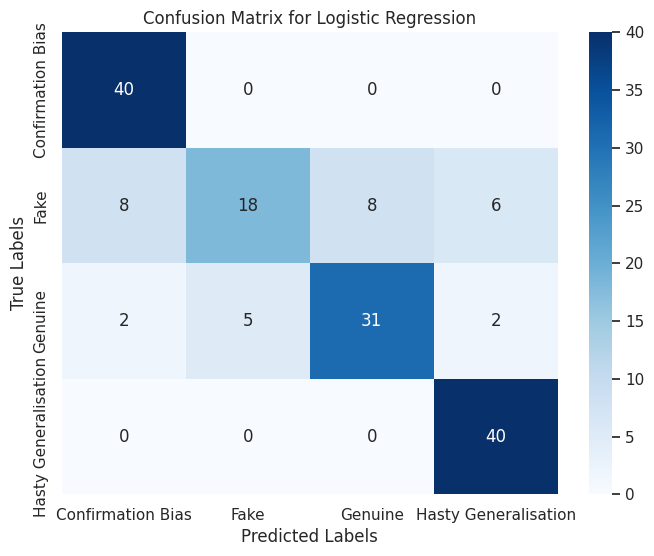

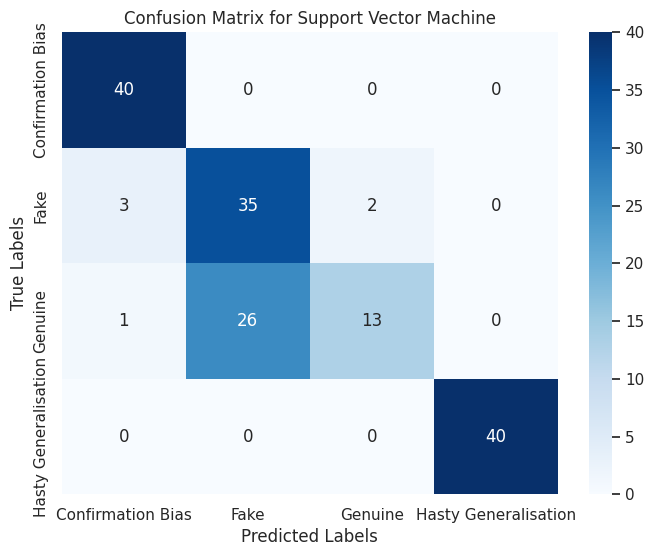

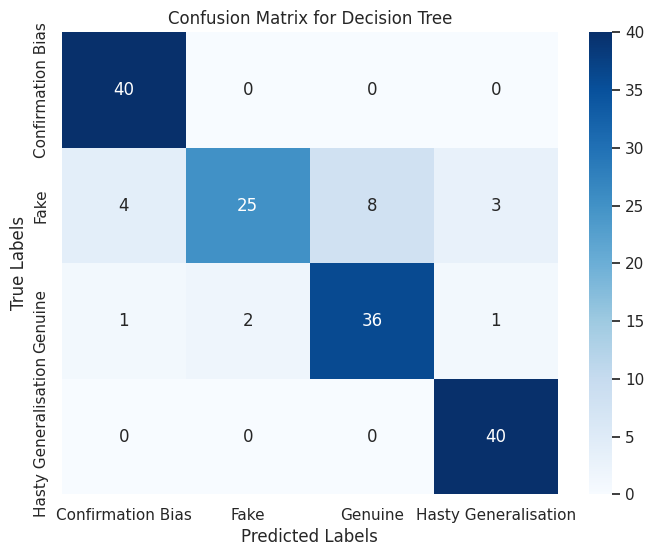

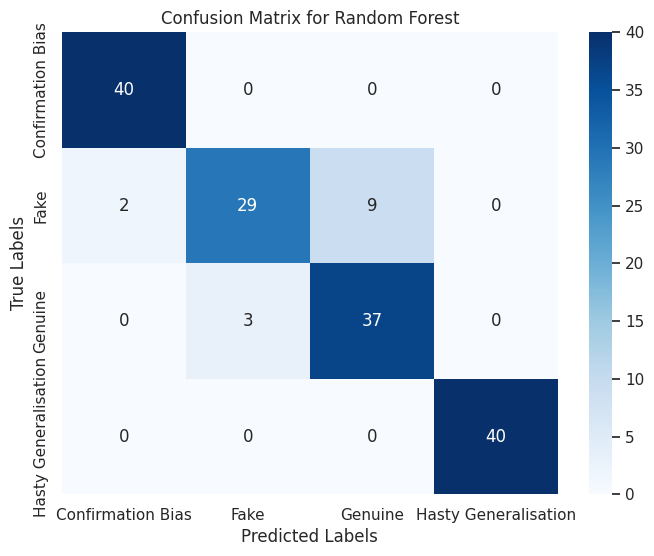

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.80625,0.802703,0.80625,0.788555
1,Support Vector Machine,0.80000,0.837382,0.80000,0.779544
2,Decision Tree,0.88125,0.885522,0.88125,0.874242
3,Random Forest,0.91250,0.915745,0.91250,0.910408


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, model_name):
  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
  plt.title(f"Confusion Matrix for {model_name}")
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.show()


# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
plot_confusion_matrix(y_test, y_pred_logreg, "Logistic Regression")
evaluate_model("Logistic Regression", y_test, y_pred_logreg, metrics)


# Support Vector Machine
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
plot_confusion_matrix(y_test, y_pred_svm, "Support Vector Machine")
evaluate_model("Support Vector Machine", y_test, y_pred_svm, metrics)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree")
evaluate_model("Decision Tree", y_test, y_pred_dt, metrics)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
evaluate_model("Random Forest", y_test, y_pred_rf, metrics)

# Convert metrics to DataFrame
metrics_df = pd.DataFrame(metrics)
metrics_df

In [ ]:
# Step 1: TF-IDF Vectorization (Original Dataset without Balancing)
print("\nOriginal Dataset - TF-IDF Vectorization")
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(rawData['Processed_Title']).toarray()
y = rawData['New Labels']

# Step 2: Scaling the Original Dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Train-Test Split (Original Dataset)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
from tqdm import tqdm  # To add a progress bar for the loop

# Step 4: Model Training and Evaluation on Original Dataset
print("\nTraining Models on Original Dataset")

# Update the models to run faster in Google Colab
models = [
    # Reduced max_iter for faster convergence. Logistic regression converges relatively fast.
    ('Softmax Logistic Regression', LogisticRegression(max_iter=150, solver='lbfgs')),

    # Changed SVM kernel to 'linear' for faster computation and reduced the number of data points for training.
    ('Support Vector Machine', SVC(kernel='linear', probability=True, max_iter=500)),

    # Reduced complexity of Decision Tree (added max_depth).
    ('Decision Trees', DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=10)),

    # Reduced number of estimators and added parallel processing for Random Forests.
    ('Random Forests', RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1))
]

# To reduce the size of training data for faster iteration during initial exploration
X_train_sample, _, y_train_sample, _ = train_test_split(X_train, y_train, test_size=0.8, random_state=42, stratify=y_train)

# Adding progress bar to the model training process
for name, model in tqdm(models, desc="Training Models"):
    model.fit(X_train_sample, y_train_sample)
    y_pred = model.predict(X_test)
    evaluate_model(name + " (Original)", y_test, y_pred, metrics)

# Displaying a message to indicate model training has finished
print("\nModel Training Completed!")


Training Models on Original Dataset


Training Models:  25%|██▌       | 1/4 [00:00<00:01,  1.94it/s]/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Training Models: 100%|██████████| 4/4 [00:00<00:00,  4.60it/s]


Model Training Completed!


In [ ]:
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Step 8: Model Training and Evaluation on SMOTE Balanced Dataset
print("\nTraining Models on SMOTE Balanced Dataset")

# Take a smaller sample from the balanced dataset for training to make it run faster
X_train_sample, _, y_train_sample, _ = train_test_split(X_train, y_train, test_size=0.8, random_state=42, stratify=y_train)

# Updated Models for Faster Training
models = [
    ('Softmax Logistic Regression', LogisticRegression(max_iter=100, solver='lbfgs')),  # Reduced max_iter for faster convergence.
    ('Support Vector Machine', SVC(kernel='linear', probability=True, max_iter=300)),  # Set max_iter to limit training time.
    ('Decision Trees', DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=8)),  # Set max_depth to limit complexity.
    ('Random Forests', RandomForestClassifier(n_estimators=20, max_depth=8, random_state=42, n_jobs=-1, warm_start=True))  # Fewer trees and shallower depth.
]

# Adding a progress bar to track the model training process
for name, model in tqdm(models, desc="Training Models on SMOTE Balanced Dataset"):
    model.fit(X_train_sample, y_train_sample)  # Using the sample of the training dataset to speed up the process
    y_pred = model.predict(X_test)
    evaluate_model(name + " (SMOTE)", y_test, y_pred, metrics)

# Displaying a message to indicate model training has finished
print("\nModel Training on SMOTE Balanced Dataset Completed!")



Training Models on SMOTE Balanced Dataset


Training Models on SMOTE Balanced Dataset:  25%|██▌       | 1/4 [00:00<00:00,  4.37it/s]/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Training Models on SMOTE Balanced Dataset: 100%|██████████| 4/4 [00:00<00:00,  6.81it/s]


Model Training on SMOTE Balanced Dataset Completed!


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

# Step 9: Random Under-Sampling - TF-IDF Vectorization (Optimized)
print("\nRandom Under-Sampling - TF-IDF Vectorization")

# Optimizing the Under-sampling Step
# Using only a portion of the dataset to reduce time consumption
X_subset, _, y_subset, _ = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# Apply Random Under-Sampling to create a balanced subset (Optimized to work on a smaller dataset)
under_sampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = under_sampler.fit_resample(X_subset, y_subset)

# Step 10: Scaling the Under-Sampled Dataset (Optimized)
# Fit the StandardScaler on the reduced dataset
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

# Step 11: Train-Test Split (Under-Sampled Dataset)
# Split resampled data into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X_resampled_scaled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Displaying message to confirm completion
print("\nRandom Under-Sampling Completed Successfully!")


Random Under-Sampling - TF-IDF Vectorization

Random Under-Sampling Completed Successfully!


In [ ]:
from tqdm import tqdm

# Step 12: Model Training and Evaluation on Random Under-Sampled Dataset (Optimized)
print("\nTraining Models on Random Under-Sampled Dataset")

# Using a smaller subset of the training data to make training faster
X_train_sample, _, y_train_sample, _ = train_test_split(X_train, y_train, test_size=0.8, random_state=42, stratify=y_train)

# Update model configurations to make them train faster
optimized_models = [
    ('Softmax Logistic Regression', LogisticRegression(max_iter=100, solver='lbfgs')),  # Reduced max_iter to limit training time
    ('Support Vector Machine', SVC(kernel='linear', max_iter=200)),  # Reduced iterations and used linear kernel
    ('Decision Trees', DecisionTreeClassifier(criterion='gini', max_depth=8, random_state=42)),  # Limited depth to reduce overfitting and computation time
    ('Random Forests', RandomForestClassifier(n_estimators=20, max_depth=8, random_state=42, n_jobs=-1, warm_start=True))  # Fewer trees, shallower, and parallel processing
]

# Adding progress bar to the model training process
for name, model in tqdm(optimized_models, desc="Training Models on Under-Sampled Dataset"):
    model.fit(X_train_sample, y_train_sample)  # Using the smaller sample for quicker evaluation
    y_pred = model.predict(X_test)
    evaluate_model(name + " (Under-Sampling)", y_test, y_pred, metrics)

# Displaying a message to indicate model training has finished
print("\nModel Training on Random Under-Sampled Dataset Completed!")



Training Models on Random Under-Sampled Dataset


Training Models on Under-Sampled Dataset:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Training Models on Under-Sampled Dataset:  25%|██▌       | 1/4 [00:00<00:01,  2.63it/s]/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_di


Model Training on Random Under-Sampled Dataset Completed!


In [ ]:
# Step 13: EasyEnsembleClassifier Balancing - TF-IDF Vectorization
print("\nEasyEnsembleClassifier - TF-IDF Vectorization")
easy_ensemble = EasyEnsembleClassifier(random_state=42, n_estimators=10)
easy_ensemble.fit(X, y)

balanced_X = []
balanced_y = []

for estimator in easy_ensemble.estimators_:
    sampled_indices = estimator[0].sample_indices_
    balanced_X.append(X[sampled_indices])
    balanced_y.append(np.array(y)[sampled_indices])

# Combine all the balanced data from each of the weak learners
balanced_X = np.vstack(balanced_X)
balanced_y = np.hstack(balanced_y)

# Step 14: Scaling the EasyEnsemble Dataset
balanced_X_scaled = scaler.fit_transform(balanced_X)

# Step 15: Train-Test Split (EasyEnsemble Dataset)
X_train, X_test, y_train, y_test = train_test_split(balanced_X_scaled, balanced_y, test_size=0.2, random_state=42, stratify=balanced_y)


EasyEnsembleClassifier - TF-IDF Vectorization


In [ ]:
# Step 16: Model Training and Evaluation on EasyEnsembleClassifier Balanced Dataset
print("\nTraining Models on EasyEnsembleClassifier Balanced Dataset")
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    evaluate_model(name + " (EasyEnsemble)", y_test, y_pred, metrics)



Training Models on EasyEnsembleClassifier Balanced Dataset


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=300).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:466: UserWarning: Warm-start fitting without increasing n_estimators does not fit new trees.
  warn(


<ipython-input-52-fb8d687a56cc>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='accuracy', data=results_df, palette='viridis')


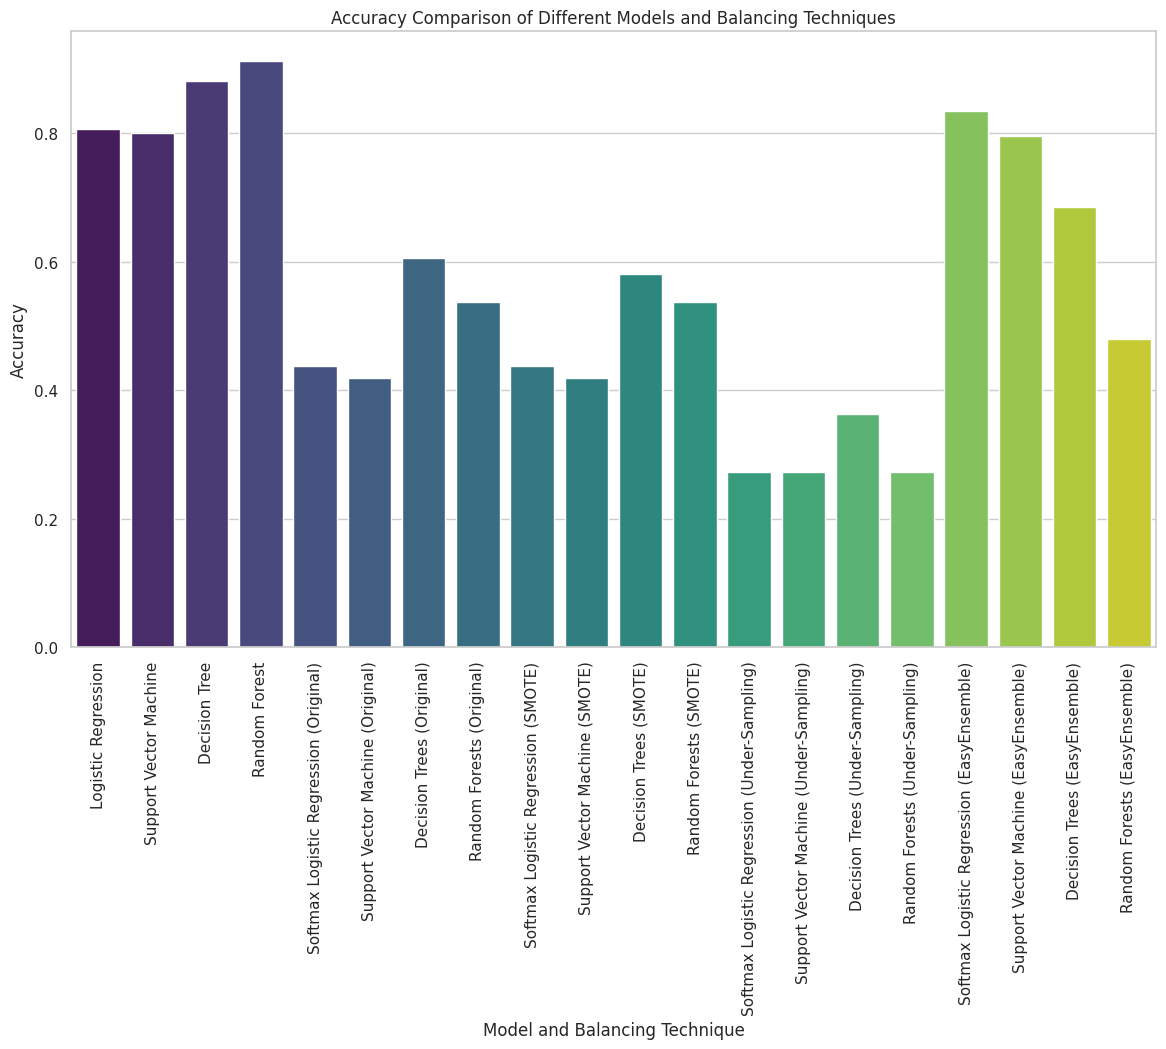


Metrics Summary:
                                           model  accuracy  precision  \
0                            Logistic Regression  0.806250   0.802703   
1                         Support Vector Machine  0.800000   0.837382   
2                                  Decision Tree  0.881250   0.885522   
3                                  Random Forest  0.912500   0.915745   
4         Softmax Logistic Regression (Original)  0.437500   0.600039   
5              Support Vector Machine (Original)  0.418750   0.473982   
6                      Decision Trees (Original)  0.606250   0.567769   
7                      Random Forests (Original)  0.537500   0.662677   
8            Softmax Logistic Regression (SMOTE)  0.437500   0.600039   
9                 Support Vector Machine (SMOTE)  0.418750   0.473982   
10                        Decision Trees (SMOTE)  0.581250   0.635213   
11                        Random Forests (SMOTE)  0.537500   0.629290   
12  Softmax Logistic Regression (

In [ ]:
# Step 17: Summary of Model Evaluations
results_df = pd.DataFrame(metrics)

# Step 18: Plot the comparison of accuracy for different models across different versions of the dataset
plt.figure(figsize=(14, 8))
sns.barplot(x='model', y='accuracy', data=results_df, palette='viridis')
plt.title('Accuracy Comparison of Different Models and Balancing Techniques')
plt.xlabel('Model and Balancing Technique')
plt.ylabel('Accuracy')
plt.xticks(rotation=90)
plt.show()

# Step 19: Display metrics summary for all models and balancing techniques
print("\nMetrics Summary:")
print(results_df)


In [ ]:
# Detect Fallacy_Special
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

data = {
    "Processed_Title": [
        "COVID causes global shutdown, everyone agrees",
        "Vaccines lead to dangerous mutations, claims researcher",
        "New study shows social media is to blame for misinformation",
        "Lockdowns have no effect, according to a single study",
        "People believe that masks are unnecessary based on one opinion"
    ],
    "New Labels": [
        "Hasty Generalisation",
        "Confirmation Bias",
        "Hasty Generalisation",
        "Hasty Generalisation",
        "Confirmation Bias"
    ]
}

# Convert sample data to DataFrame
sample_df = pd.DataFrame(data)

# Step 2: Feature Extraction using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(sample_df['Processed_Title']).toarray()
y = sample_df['New Labels']  # Target labels: Hasty Generalisation, Confirmation Bias

# Step 3: Split Data into Train-Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=2, random_state=42, stratify=y)

# Step 4: Train Traditional Models
# Logistic Regression Model
lr_model = LogisticRegression(max_iter=300, solver='lbfgs')
lr_model.fit(X_train, y_train)

# Support Vector Machine Model
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

# Step 5: Make Predictions
lr_predictions = lr_model.predict(X_test)
svm_predictions = svm_model.predict(X_test)

# Step 6: Evaluate the Models
print("\nLogistic Regression Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, lr_predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions, target_names=["Hasty Generalisation", "Confirmation Bias"]))

print("\nSupport Vector Machine Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, svm_predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, svm_predictions, target_names=["Hasty Generalisation", "Confirmation Bias"]))


Logistic Regression Evaluation:
Accuracy: 0.5000

Classification Report:
                      precision    recall  f1-score   support

Hasty Generalisation       0.00      0.00      0.00         1
   Confirmation Bias       0.50      1.00      0.67         1

            accuracy                           0.50         2
           macro avg       0.25      0.50      0.33         2
        weighted avg       0.25      0.50      0.33         2


Support Vector Machine Evaluation:
Accuracy: 0.5000

Classification Report:
                      precision    recall  f1-score   support

Hasty Generalisation       0.00      0.00      0.00         1
   Confirmation Bias       0.50      1.00      0.67         1

            accuracy                           0.50         2
           macro avg       0.25      0.50      0.33         2
        weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
from sklearn.metrics import classification_report

print("\nCNN Evaluation:")
y_pred_cnn = cnn_model.predict(X_test)
y_pred_cnn = np.argmax(y_pred_cnn, axis=1) # Convert probabilities to class labels
y_test_cnn = np.argmax(y_test, axis = 1) # Convert one-hot encoded y_test to class labels
print(classification_report(y_test_cnn, y_pred_cnn))


# LSTM Evaluation
print("\nLSTM Evaluation:")
y_pred_lstm = lstm_model.predict(X_test)
y_pred_lstm = np.argmax(y_pred_lstm, axis=1) # Convert probabilities to class labels
y_test_lstm = np.argmax(y_test, axis=1) # Convert one-hot encoded y_test to class labels
print(classification_report(y_test_lstm,y_pred_lstm))


CNN Evaluation:
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           0       0.02      0.18      0.03        11
           1       0.00      0.00      0.00         1
           2       0.95      0.87      0.91      2112
           3       0.85      0.83      0.84       765
           4       0.01      0.20      0.03         5

    accuracy                           0.86      2894
   macro avg       0.37      0.42      0.36      2894
weighted avg       0.92      0.86      0.89      2894


LSTM Evaluation:
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.00      0.00      0.00         1
           2       0.96      0.83      0.89      2112
           3       0.80      0.85      0.83       765
           4       0.01      0.20      0.03         5

    accuracy                           0.83      2894
   macro avg      

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



Loading and Preparing Data

Step 1: Text Preprocessing

Step 2: Tokenization and Padding

Step 3: Train-Test Split

Step 4: Handling Class Imbalance with SMOTE and Random Under-Sampling

SMOTE Resampling Successful

Step 5: Training and Evaluation of Deep Learning Models


Training on Different Datasets:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
181/181 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8032 - loss: 0.5100 - val_accuracy: 0.9416 - val_loss: 0.1795
Epoch 2/3
181/181 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9690 - loss: 0.1120 - val_accuracy: 0.9471 - val_loss: 0.1709
Epoch 3/3
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9873 - loss: 0.0596 - val_accuracy: 0.9447 - val_loss: 0.2004
Epoch 1/3
181/181 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7669 - loss: 0.6135 - val_accuracy: 0.9381 - val_loss: 0.1884
Epoch 2/3
181/181 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9659 - loss: 0.1171 - val_accuracy: 0.9430 - val_loss: 0.1697
Epoch 3/3
181/181 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9790 - loss: 0.0848 - val_accuracy: 0.9499 - val_loss: 0.1749


Training on Different Datasets:  33%|███▎      | 1/3 [00:29<00:59, 29.69s/it]

Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2000 - loss: 1.6113 - val_accuracy: 0.1835 - val_loss: 1.5929
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.2667 - loss: 1.5943 - val_accuracy: 0.4724 - val_loss: 1.5924
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.5333 - loss: 1.5752 - val_accuracy: 0.1676 - val_loss: 1.6089
Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2667 - loss: 1.6076 - val_accuracy: 0.1175 - val_loss: 1.6137
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.6667 - loss: 1.5947 - val_accuracy: 0.1189 - val_loss: 1.6172
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.7333 - loss: 1.5817 - val_accuracy: 0.1303 - val_loss: 1.6199


Training on Different Datasets:  67%|██████▋   | 2/3 [00:37<00:17, 17.05s/it]

Epoch 1/3
660/660 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5770 - loss: 1.0082 - val_accuracy: 0.7519 - val_loss: 0.6787
Epoch 2/3
660/660 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9060 - loss: 0.2795 - val_accuracy: 0.8234 - val_loss: 0.5064
Epoch 3/3
660/660 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9680 - loss: 0.1077 - val_accuracy: 0.8587 - val_loss: 0.4901
Epoch 1/3
660/660 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5512 - loss: 1.0872 - val_accuracy: 0.7592 - val_loss: 0.6297
Epoch 2/3
660/660 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8612 - loss: 0.4021 - val_accuracy: 0.8407 - val_loss: 0.4408
Epoch 3/3
660/660 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9329 - loss: 0.2059 - val_accuracy: 0.8348 - val_loss: 0.4892


Training on Different Datasets: 100%|██████████| 3/3 [01:22<00:00, 27.35s/it]



Step 6: Model Evaluation and Comparison

Metrics Summary for Deep Learning Models:
  model         dataset  accuracy
0   CNN        Original  0.944713
1  LSTM        Original  0.949896
2   CNN  Under-Sampling  0.167588
3  LSTM  Under-Sampling  0.130270
4   CNN           SMOTE  0.858673
5  LSTM           SMOTE  0.834831


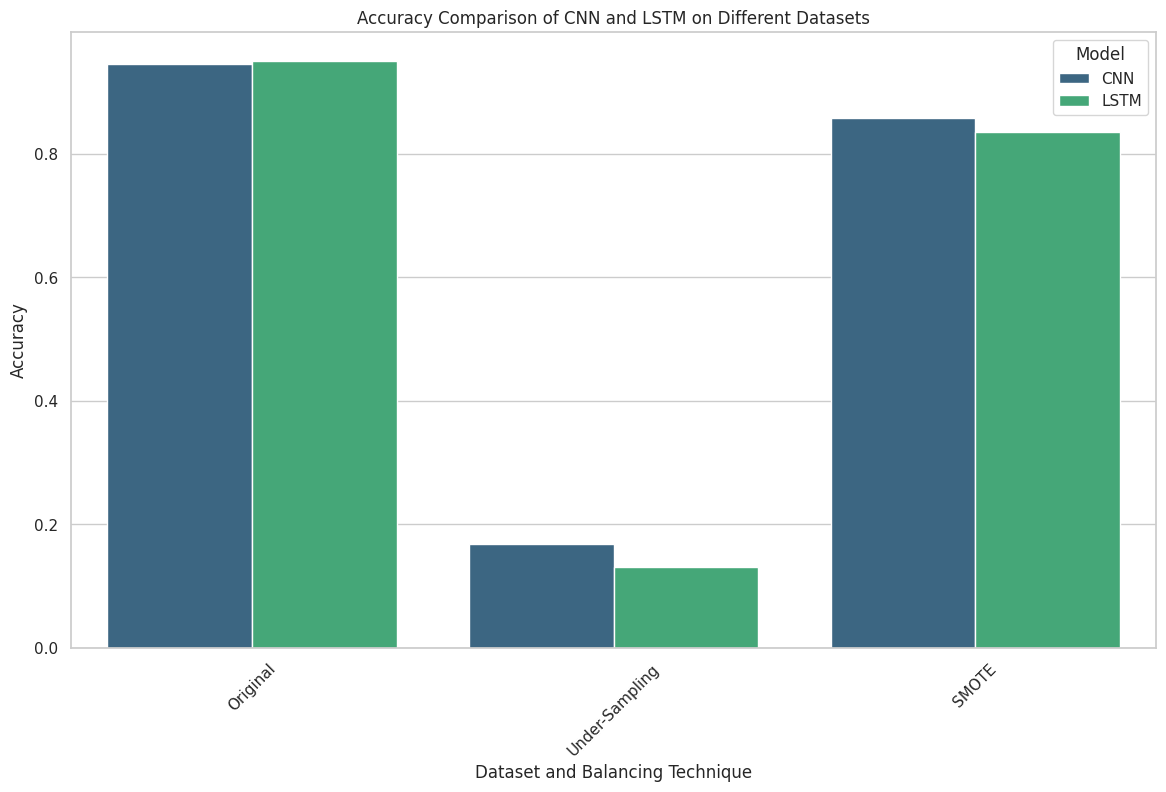

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Embedding, LSTM
from tqdm import tqdm
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Load Data
print("\nLoading and Preparing Data")
file_path = '/content/New Data for Social Media Covid 19.xlsx'  # Update file path
rawData = pd.read_excel(file_path)

# Step 1: Text Preprocessing
print("\nStep 1: Text Preprocessing")

# Initialize NLP tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Remove non-alphabetic characters
    text = re.sub(r'[^A-Za-z\s]', '', str(text))
    # Convert to lowercase
    text = text.lower()
    # Tokenization and removing stopwords
    tokens = [word for word in text.split() if word not in stop_words]
    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

# Apply preprocessing to the 'Title' column
rawData['Processed_Title'] = rawData['Title'].apply(preprocess_text)

# Step 2: Tokenization and Padding for Deep Learning
print("\nStep 2: Tokenization and Padding")
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=5000)
tokenizer.fit_on_texts(rawData['Processed_Title'])
X_sequences = tokenizer.texts_to_sequences(rawData['Processed_Title'])
X_padded = tf.keras.preprocessing.sequence.pad_sequences(X_sequences, maxlen=100)
y = pd.get_dummies(rawData['New Labels']).values

# Step 3: Train-Test Split
print("\nStep 3: Train-Test Split")
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Handling Class Imbalance (SMOTE and Random Under-Sampling)
print("\nStep 4: Handling Class Imbalance with SMOTE and Random Under-Sampling")

# Set n_neighbors=2 to handle the issue where some classes have fewer samples
smote = SMOTE(random_state=42, k_neighbors=2)
try:
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print("\nSMOTE Resampling Successful")
except ValueError as e:
    print(f"SMOTE could not be applied: {e}. Proceeding with original data without SMOTE.")

under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train, y_train)

# Step 5: Deep Learning Model Training - CNN and LSTM

# Define function to create CNN model
def create_cnn(input_length, output_dim):
    model = Sequential([
        Embedding(input_dim=5000, output_dim=128, input_length=input_length),
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Define function to create LSTM model
def create_lstm(input_length, output_dim):
    model = Sequential([
        Embedding(input_dim=5000, output_dim=128, input_length=input_length),
        LSTM(128),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Store metrics for comparison
metrics = {'model': [], 'dataset': [], 'accuracy': []}

# Train and Evaluate Deep Learning Models for Different Scenarios
datasets = [
    ('Original', X_train, y_train),
    ('Under-Sampling', X_train_under, y_train_under)
]

# Add SMOTE Dataset if available
if 'X_train_smote' in locals():
    datasets.append(('SMOTE', X_train_smote, y_train_smote))

# Train and Evaluate CNN and LSTM models on each dataset
print("\nStep 5: Training and Evaluation of Deep Learning Models")
for dataset_name, X_train_data, y_train_data in tqdm(datasets, desc="Training on Different Datasets"):

    # CNN Model
    cnn_model = create_cnn(input_length=100, output_dim=y.shape[1])
    cnn_model.fit(X_train_data, y_train_data, epochs=3, batch_size=64, validation_data=(X_test, y_test), verbose=1)
    cnn_eval = cnn_model.evaluate(X_test, y_test, verbose=0)
    metrics['model'].append('CNN')
    metrics['dataset'].append(dataset_name)
    metrics['accuracy'].append(cnn_eval[1])

    # LSTM Model
    lstm_model = create_lstm(input_length=100, output_dim=y.shape[1])
    lstm_model.fit(X_train_data, y_train_data, epochs=3, batch_size=64, validation_data=(X_test, y_test), verbose=1)
    lstm_eval = lstm_model.evaluate(X_test, y_test, verbose=0)
    metrics['model'].append('LSTM')
    metrics['dataset'].append(dataset_name)
    metrics['accuracy'].append(lstm_eval[1])

# Step 6: Model Evaluation and Comparison
print("\nStep 6: Model Evaluation and Comparison")
results_df = pd.DataFrame(metrics)
print("\nMetrics Summary for Deep Learning Models:")
print(results_df)

# Plot accuracy comparison
plt.figure(figsize=(14, 8))
sns.barplot(x='dataset', y='accuracy', hue='model', data=results_df, palette='viridis')
plt.title('Accuracy Comparison of CNN and LSTM on Different Datasets')
plt.xlabel('Dataset and Balancing Technique')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.show()


In [ ]:
import pickle
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the directory where you want to save the models
save_dir = '/content/drive/MyDrive/trained_models'  # Change this to your desired path

# ... (your existing code) ...

# After training each model, save it using pickle
for name, model in models:
    model_filename = f'{name.replace(" ", "_")}.pkl'
    model_path = f'{save_dir}/{model_filename}'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved {name} model to {model_path}")


# Save the other models similarly
# ... (Logistic Regression, SVM, Random Forest, Decision Tree)

#Example for Logistic Regression (assuming lr_model is your trained model):
model_filename = 'Logistic_Regression_Model.pkl'
model_path = f'{save_dir}/{model_filename}'
with open(model_path, 'wb') as f:
  pickle.dump(lr_model,f)
print(f"Saved Logistic Regression model to {model_path}")


# Example for SVM
model_filename = 'SVM_Model.pkl'
model_path = f'{save_dir}/{model_filename}'
with open(model_path, 'wb') as f:
  pickle.dump(svm_model,f)
print(f"Saved SVM model to {model_path}")

#Example for CNN
model_filename = 'CNN_Model.h5' #Use .h5 for Keras models
model_path = f'{save_dir}/{model_filename}'
cnn_model.save(model_path) #Use .save() for Keras models
print(f"Saved CNN model to {model_path}")

# Example for LSTM
model_filename = 'LSTM_Model.h5' # Use .h5 for Keras models
model_path = f'{save_dir}/{model_filename}'
lstm_model.save(model_path) # Use .save() for Keras models
print(f"Saved LSTM model to {model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved Softmax Logistic Regression model to /content/drive/MyDrive/trained_models/Softmax_Logistic_Regression.pkl
Saved Support Vector Machine model to /content/drive/MyDrive/trained_models/Support_Vector_Machine.pkl
Saved Decision Trees model to /content/drive/MyDrive/trained_models/Decision_Trees.pkl
Saved Random Forests model to /content/drive/MyDrive/trained_models/Random_Forests.pkl
Saved Logistic Regression model to /content/drive/MyDrive/trained_models/Logistic_Regression_Model.pkl
Saved SVM model to /content/drive/MyDrive/trained_models/SVM_Model.pkl
Saved CNN model to /content/drive/MyDrive/trained_models/CNN_Model.h5
Saved LSTM model to /content/drive/MyDrive/trained_models/LSTM_Model.h5
